# SeqDefender Phase 2: BiLSTM + Attention + SHAP

This notebook upgrades the baseline model to an attention-based BiLSTM pipeline with SHAP explainability and deployment-ready artifacts.

In [14]:
# Optional bootstrap for missing dependencies
import importlib
import subprocess
import sys

def ensure_package(import_name, pip_name=None):
    package_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("imblearn", "imbalanced-learn")
ensure_package("shap")
ensure_package("joblib")

In [15]:
import json
import os
import random

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, f1_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, BatchNormalization, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [16]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = "data_file.csv"
DROP_COLUMNS = ["FileName", "md5Hash"]
LABEL_COLUMN = None
ARTIFACT_DIR = "artifacts_phase2"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)

TensorFlow: 2.18.0
SHAP: 0.47.2


In [17]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at '{DATA_PATH}'. Update DATA_PATH first.")

df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)

for col in DROP_COLUMNS:
    if col in df.columns:
        df = df.drop(columns=[col])

df = df.drop_duplicates().reset_index(drop=True)
label_col = df.columns[-1] if LABEL_COLUMN is None else LABEL_COLUMN

X_df = df.drop(columns=[label_col]).copy()
non_numeric_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_cols:
    print("Dropping non-numeric columns:", non_numeric_cols)
    X_df = X_df.drop(columns=non_numeric_cols)

feature_names = X_df.columns.tolist()
X = X_df.values.astype(np.float32)

y_raw = df[label_col]
if np.issubdtype(y_raw.dtype, np.number):
    y = y_raw.astype(int).values
else:
    y, uniques = pd.factorize(y_raw)
    print("Label mapping:", {int(i): str(v) for i, v in enumerate(uniques)})

if np.unique(y).size != 2:
    raise ValueError("Binary labels required for this pipeline.")

print("Prepared shape:", X.shape)
print("Label distribution:", dict(zip(*np.unique(y, return_counts=True))))

Raw shape: (62485, 18)
Prepared shape: (32256, 15)
Label distribution: {np.int64(0): np.int64(10683), np.int64(1): np.int64(21573)}


In [18]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Train before SMOTE:", X_train_scaled.shape)
print("Train after SMOTE:", X_train_balanced.shape)
print("Train class balance:", dict(zip(*np.unique(y_train_balanced, return_counts=True))))

Train before SMOTE: (20643, 15)
Train after SMOTE: (27612, 15)
Train class balance: {np.int64(0): np.int64(13806), np.int64(1): np.int64(13806)}


In [19]:
GROUP_KEYWORDS = {
    "header": ["machine", "characteristics", "entry", "imagebase", "subsystem", "dll", "size"],
    "section": ["section", "virtual", "raw", "code", "data", "pointer"],
    "import_export": ["import", "export", "iat", "eot", "api", "thunk"],
    "resource": ["resource", "rsrc", "icon", "version", "manifest"],
    "entropy": ["entropy", "packed", "compress", "random"],
    "string": ["string", "ascii", "unicode", "url", "path", "registry"],
    "behavior_proxy": ["suspicious", "process", "thread", "network", "mutex", "write"]
}
STAT_NAMES = ["mean", "std", "min", "max"]

def assign_group(feature_name):
    name = feature_name.lower()
    for group_name, keywords in GROUP_KEYWORDS.items():
        if any(k in name for k in keywords):
            return group_name
    return "other"

feature_groups = {}
for idx, fname in enumerate(feature_names):
    group = assign_group(fname)
    feature_groups.setdefault(group, []).append(idx)
group_names = sorted(feature_groups.keys())

def build_grouped_sequences(X_matrix):
    seq = np.zeros((X_matrix.shape[0], len(group_names), len(STAT_NAMES)), dtype=np.float32)
    for g_idx, g_name in enumerate(group_names):
        group_values = X_matrix[:, feature_groups[g_name]]
        seq[:, g_idx, 0] = np.mean(group_values, axis=1)
        seq[:, g_idx, 1] = np.std(group_values, axis=1)
        seq[:, g_idx, 2] = np.min(group_values, axis=1)
        seq[:, g_idx, 3] = np.max(group_values, axis=1)
    return seq

X_train_seq = build_grouped_sequences(X_train_balanced)
X_val_seq = build_grouped_sequences(X_val_scaled)
X_test_seq = build_grouped_sequences(X_test_scaled)

flat_feature_names = [f"{g}_{s}" for g in group_names for s in STAT_NAMES]

print("Sequence shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)
print("Groups:", group_names)

Sequence shapes: (27612, 5, 4) (5161, 5, 4) (6452, 5, 4)
Groups: ['header', 'import_export', 'other', 'resource', 'section']


In [20]:
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.score_dense = Dense(1)

    def call(self, lstm_output):
        score = self.score_dense(lstm_output)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * lstm_output, axis=1)
        return context, weights

inputs = Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2]), name="sequence_input")
x = Bidirectional(LSTM(128, return_sequences=True), name="bilstm_1")(inputs)
x = Dropout(0.3, name="dropout_1")(x)
x = Bidirectional(LSTM(64, return_sequences=True), name="bilstm_2")(x)
context, attention_weights = AttentionLayer(name="attention_layer")(x)
x = Dense(64, activation="relu", name="dense_1")(context)
x = BatchNormalization(name="batch_norm_1")(x)
outputs = Dense(1, activation="sigmoid", name="prediction")(x)

model = Model(inputs=inputs, outputs=outputs, name="bilstm_attention_detector")
attn_model = Model(inputs=inputs, outputs=[outputs, attention_weights], name="bilstm_attention_with_weights")

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "bilstm_attention_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)          │ (None, 5, 4)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm_1 (Bidirectional)             │ (None, 5, 256)              │         136,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bilstm_2 (Bidirectional)             │ (None, 5, 128)              │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer (AttentionLayer)     │ [(None, 128), (None, 5, 1)] │             129 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_norm_1 (BatchNormalization)    │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prediction (Dense)                   │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 309,250 (1.18 MB)

 Trainable params: 309,122 (1.18 MB)

 Non-trainable params: 128 (512.00 B)

In [21]:
callbacks = [
    EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-5)
]

history = model.fit(
    X_train_seq,
    y_train_balanced,
    validation_data=(X_val_seq, y_val),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
432/432 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9009 - auc: 0.9568 - loss: 0.2653 - precision: 0.8995 - recall: 0.9027 - val_accuracy: 0.9388 - val_auc: 0.9765 - val_loss: 0.1946 - val_precision: 0.9501 - val_recall: 0.9589 - learning_rate: 0.0010
Epoch 2/40
432/432 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9274 - auc: 0.9757 - loss: 0.1965 - precision: 0.9234 - recall: 0.9322 - val_accuracy: 0.9401 - val_auc: 0.9834 - val_loss: 0.1725 - val_precision: 0.9813 - val_recall: 0.9282 - learning_rate: 0.0010
Epoch 3/40
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9411 - auc: 0.9840 - loss: 0.1557 - precision: 0.9480 - recall: 0.9334 - val_accuracy: 0.9471 - val_auc: 0.9862 - val_loss: 0.1358 - val_precision: 0.9763 - val_recall: 0.9438 - learning_rate: 0.0010
Epoch 4/40
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9487 - auc: 0.9867 - loss: 0.1383 - precision: 0.9586 - recall: 0.9379 - val_accuracy: 0.9566 - val_auc: 0.9883 - val_loss: 0.1220 

In [22]:
y_prob = model.predict(X_test_seq, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)
test_f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
test_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print(f"Accuracy: {test_accuracy:.4f}")
print(f"AUC: {test_auc:.4f}")
print(f"F1: {test_f1:.4f}")
print(f"FNR: {test_fnr:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Ransomware"]))

comparison_table = pd.DataFrame([
    {"Model": "Logistic Regression", "Accuracy": np.nan, "AUC": np.nan, "F1": np.nan, "FNR": np.nan},
    {"Model": "Random Forest", "Accuracy": np.nan, "AUC": np.nan, "F1": np.nan, "FNR": np.nan},
    {"Model": "Phase 1 LSTM", "Accuracy": 0.98, "AUC": 0.98, "F1": np.nan, "FNR": np.nan},
    {"Model": "Phase 2 BiLSTM+Attn", "Accuracy": test_accuracy, "AUC": test_auc, "F1": test_f1, "FNR": test_fnr}
])
comparison_table

Accuracy: 0.9789
AUC: 0.9967
F1: 0.9842
FNR: 0.0178

Confusion Matrix:
[[2078   59]
 [  77 4238]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97      2137
  Ransomware       0.99      0.98      0.98      4315

    accuracy                           0.98      6452
   macro avg       0.98      0.98      0.98      6452
weighted avg       0.98      0.98      0.98      6452



,Model,Accuracy,AUC,F1,FNR
0,Logistic Regression,NaN,NaN,NaN,NaN
1,Random Forest,NaN,NaN,NaN,NaN
2,Phase 1 LSTM,0.980000,0.980000,NaN,NaN
3,Phase 2 BiLSTM+Attn,0.978921,0.996662,0.984208,0.017845


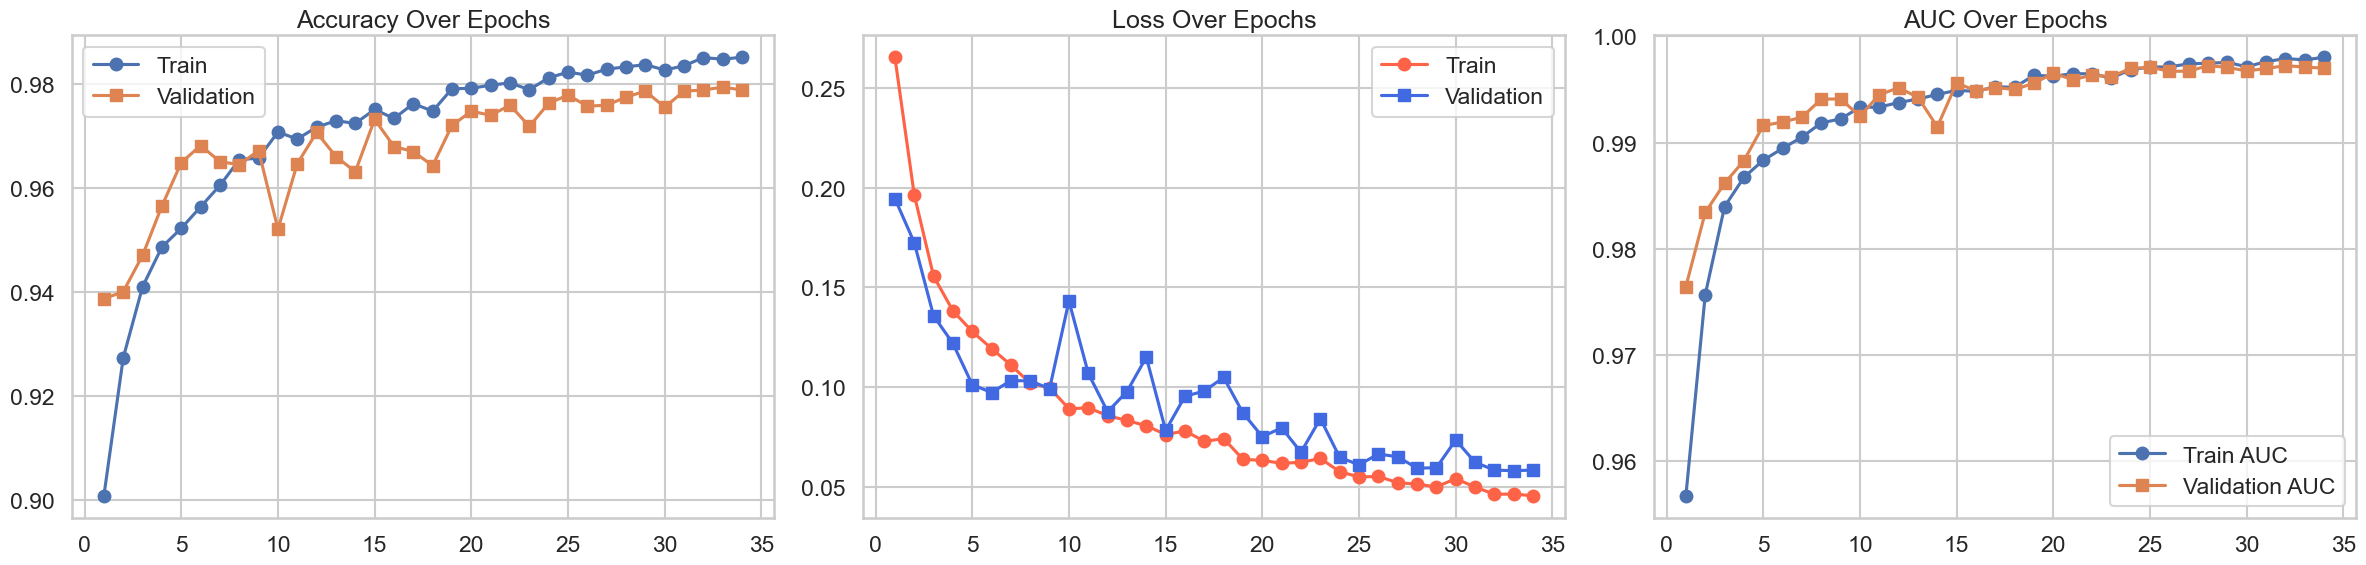

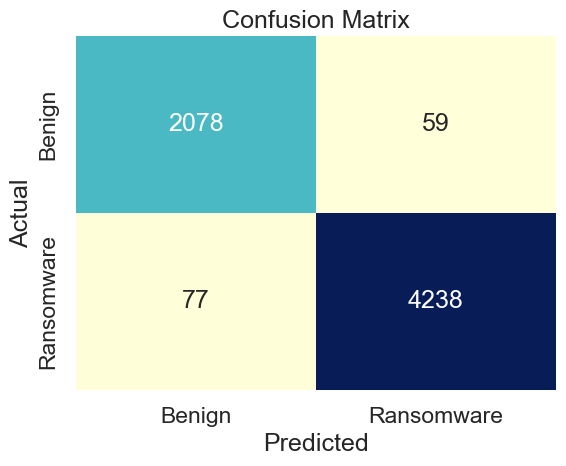

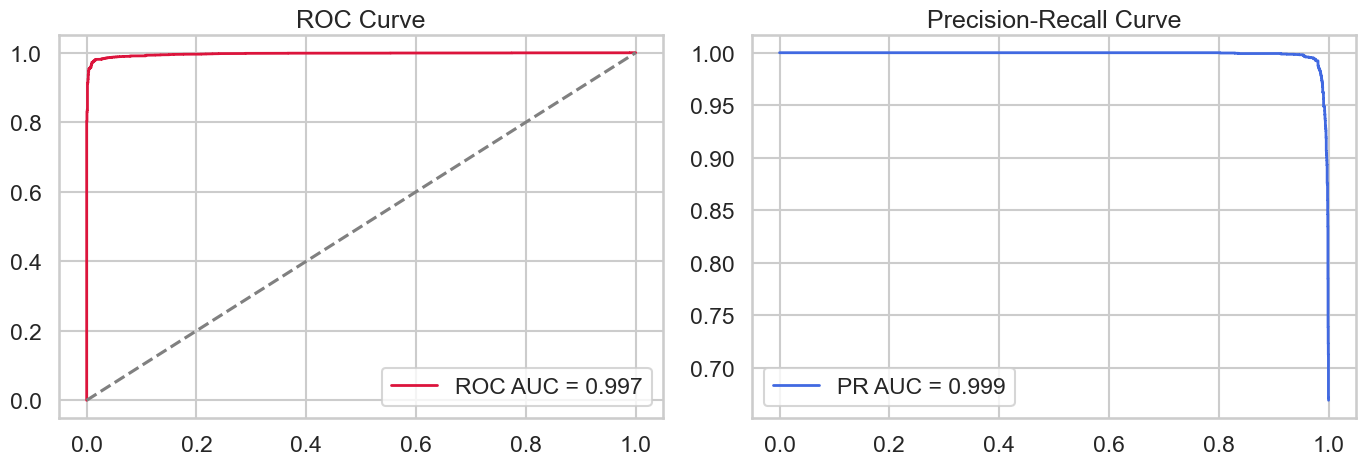

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
epochs = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs, history.history["accuracy"], marker="o", label="Train")
axes[0].plot(epochs, history.history["val_accuracy"], marker="s", label="Validation")
axes[0].set_title("Accuracy Over Epochs")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], marker="o", color="tomato", label="Train")
axes[1].plot(epochs, history.history["val_loss"], marker="s", color="royalblue", label="Validation")
axes[1].set_title("Loss Over Epochs")
axes[1].legend()

if "auc" in history.history and "val_auc" in history.history:
    axes[2].plot(epochs, history.history["auc"], marker="o", label="Train AUC")
    axes[2].plot(epochs, history.history["val_auc"], marker="s", label="Validation AUC")
    axes[2].set_title("AUC Over Epochs")
    axes[2].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False, xticklabels=["Benign", "Ransomware"], yticklabels=["Benign", "Ransomware"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color="crimson", lw=2, label=f"ROC AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

axes[1].plot(recall, precision, color="royalblue", lw=2, label=f"PR AUC = {pr_auc:.3f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

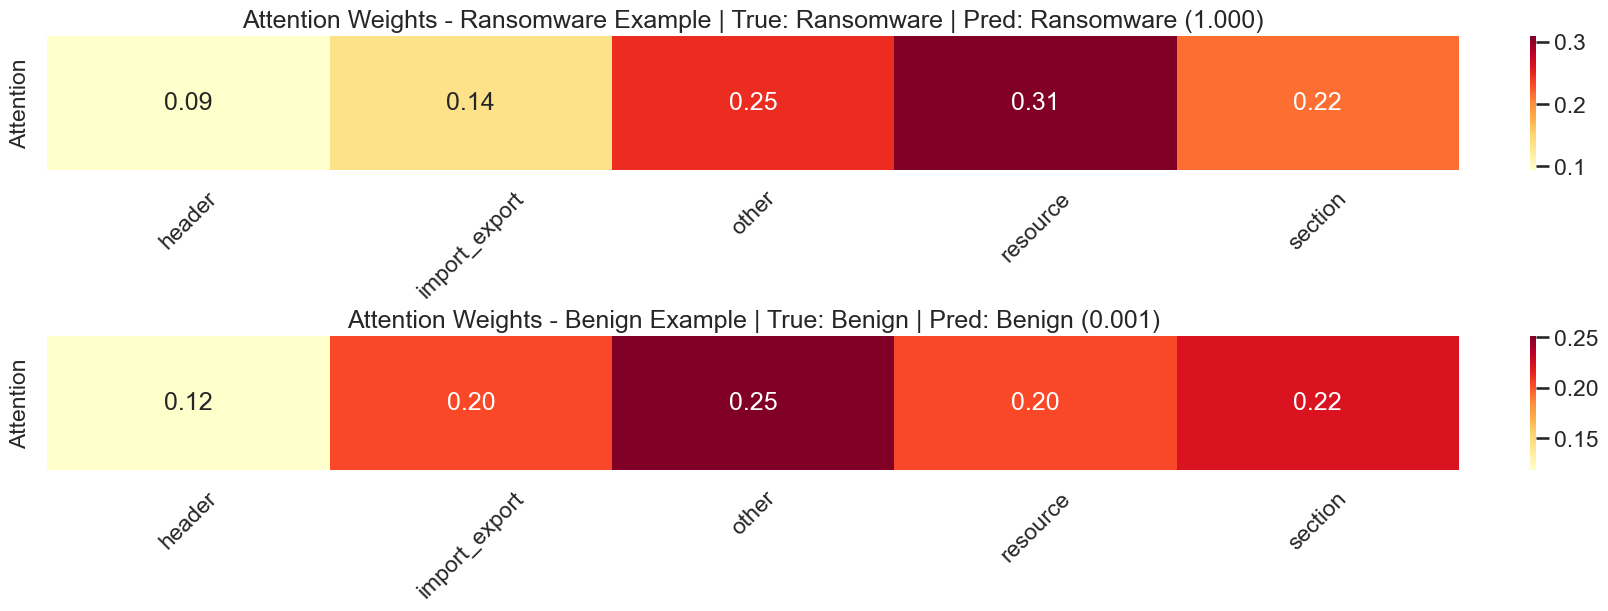

In [24]:
def plot_attention_for_sample(sample_index, ax, title):
    sample = X_test_seq[sample_index:sample_index + 1]
    pred, weights = attn_model.predict(sample, verbose=0)
    weights = weights[0, :, 0]
    sns.heatmap(weights.reshape(1, -1), ax=ax, xticklabels=group_names, yticklabels=["Attention"], cmap="YlOrRd", annot=True, fmt=".2f")
    pred_label = "Ransomware" if pred[0, 0] >= 0.5 else "Benign"
    true_label = "Ransomware" if y_test[sample_index] == 1 else "Benign"
    ax.set_title(f"{title} | True: {true_label} | Pred: {pred_label} ({pred[0, 0]:.3f})")
    ax.tick_params(axis="x", rotation=45)

ransom_indices = np.where(y_test == 1)[0]
benign_indices = np.where(y_test == 0)[0]
ransom_idx = int(ransom_indices[0]) if len(ransom_indices) > 0 else 0
benign_idx = int(benign_indices[0]) if len(benign_indices) > 0 else 0

fig, axes = plt.subplots(2, 1, figsize=(16, 6), constrained_layout=True)
plot_attention_for_sample(ransom_idx, axes[0], "Attention Weights - Ransomware Example")
plot_attention_for_sample(benign_idx, axes[1], "Attention Weights - Benign Example")
plt.show()

c:\Users\asus laptop\Downloads\Ransomware-detection-using-LSTM-main\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: sequence_input
Received: inputs=['Tensor(shape=(100, 5, 4))']
  warnings.warn(msg)
c:\Users\asus laptop\Downloads\Ransomware-detection-using-LSTM-main\.venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: sequence_input
Received: inputs=['Tensor(shape=(50, 5, 4))']
  warnings.warn(msg)
C:\Users\asus laptop\AppData\Local\Temp\ipykernel_28540\174744174.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_flat, features=samples_flat, feature_names=flat_feature_names, show=False)


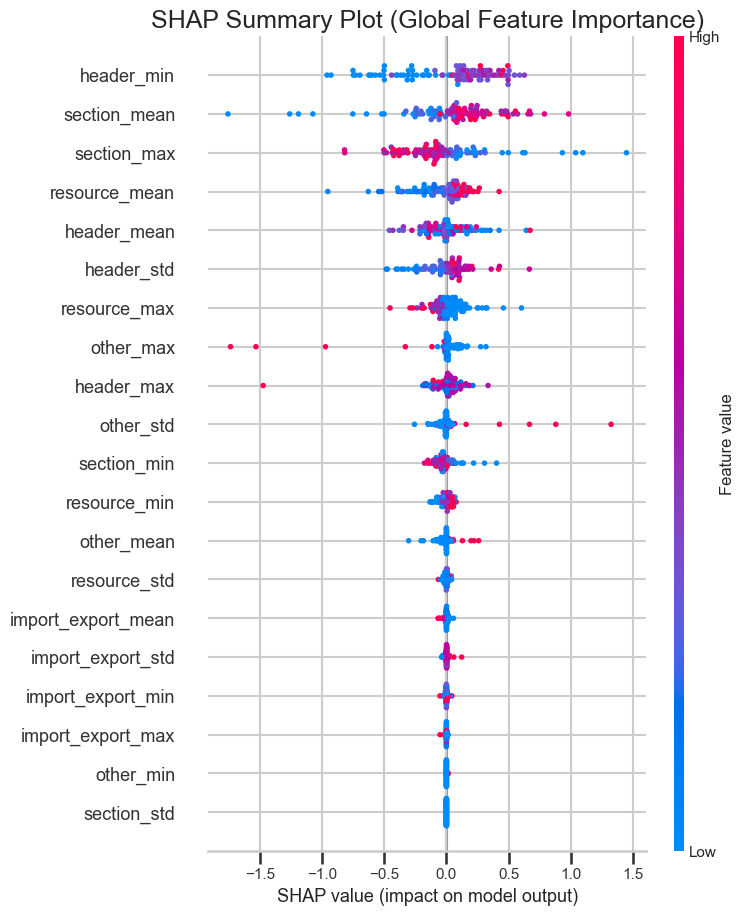

AttributeError: 'GradientExplainer' object has no attribute 'expected_value'

In [25]:
BACKGROUND_SAMPLES = min(200, X_train_seq.shape[0])
EXPLAIN_SAMPLES = min(100, X_test_seq.shape[0])
background = X_train_seq[:BACKGROUND_SAMPLES]
samples_to_explain = X_test_seq[:EXPLAIN_SAMPLES]

explainer = shap.GradientExplainer(model, background)
raw_shap_values = explainer.shap_values(samples_to_explain)

if isinstance(raw_shap_values, list):
    shap_values = np.array(raw_shap_values[0])
else:
    shap_values = np.array(raw_shap_values)

if shap_values.ndim == 4 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]

samples_flat = samples_to_explain.reshape(samples_to_explain.shape[0], -1)
shap_flat = shap_values.reshape(shap_values.shape[0], -1)

plt.figure(figsize=(14, 8))
shap.summary_plot(shap_flat, features=samples_flat, feature_names=flat_feature_names, show=False)
plt.title("SHAP Summary Plot (Global Feature Importance)")
plt.tight_layout()
plt.show()

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

y_test_subset = y_test[:EXPLAIN_SAMPLES]
ransom_idx_local = int(np.where(y_test_subset == 1)[0][0]) if np.any(y_test_subset == 1) else 0
benign_idx_local = int(np.where(y_test_subset == 0)[0][0]) if np.any(y_test_subset == 0) else 0

_ = shap.force_plot(expected_value, shap_flat[ransom_idx_local], samples_flat[ransom_idx_local], feature_names=flat_feature_names, matplotlib=True, show=True)
_ = shap.force_plot(expected_value, shap_flat[benign_idx_local], samples_flat[benign_idx_local], feature_names=flat_feature_names, matplotlib=True, show=True)

In [ ]:
model_path = os.path.join(ARTIFACT_DIR, "bilstm_attention_model.keras")
attn_model_path = os.path.join(ARTIFACT_DIR, "bilstm_attention_with_weights.keras")
scaler_path = os.path.join(ARTIFACT_DIR, "scaler.pkl")
feature_names_path = os.path.join(ARTIFACT_DIR, "feature_names.json")
group_config_path = os.path.join(ARTIFACT_DIR, "group_config.json")

model.save(model_path)
attn_model.save(attn_model_path)
joblib.dump(scaler, scaler_path)

with open(feature_names_path, "w", encoding="utf-8") as fp:
    json.dump(feature_names, fp, indent=2)

serializable_groups = {k: [int(x) for x in v] for k, v in feature_groups.items()}
with open(group_config_path, "w", encoding="utf-8") as fp:
    json.dump({"group_names": group_names, "groups": serializable_groups, "stats": STAT_NAMES}, fp, indent=2)

print("Saved artifacts:")
print(" -", model_path)
print(" -", attn_model_path)
print(" -", scaler_path)
print(" -", feature_names_path)
print(" -", group_config_path)

def prepare_single_sample(raw_feature_vector):
    raw_feature_vector = np.asarray(raw_feature_vector, dtype=np.float32).reshape(1, -1)
    if raw_feature_vector.shape[1] != len(feature_names):
        raise ValueError(f"Expected {len(feature_names)} features, got {raw_feature_vector.shape[1]}")
    scaled = scaler.transform(raw_feature_vector)
    return build_grouped_sequences(scaled)

def predict_single_sample(raw_feature_vector):
    sequence = prepare_single_sample(raw_feature_vector)
    prob, weights = attn_model.predict(sequence, verbose=0)
    probability = float(prob[0, 0])
    return {
        "label": "Ransomware" if probability >= 0.5 else "Benign",
        "probability": probability,
        "attention_weights": weights[0, :, 0].tolist(),
        "group_names": group_names
    }

sample_result = predict_single_sample(X_test[0])
sample_result